# Jacobian & Chain Rule

把导数从"标量对标量"推广到"向量对向量"：**Jacobian 矩阵**是多元函数的局部线性化矩阵，**向量链式法则**就是 Jacobian 连乘——这正是反向传播的数学本质。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 多输入多输出：Jacobian 矩阵


### 1.1 定义

$f: \mathbb{R}^n \to \mathbb{R}^m$（$n$ 个输入、$m$ 个输出），导数是一个 $m \times n$ 矩阵：

$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

- 每**行** $i$ = 第 $i$ 个输出对全部输入的偏导（是一个梯度行向量）
- 每**列** $j$ = 全部输出对第 $j$ 个输入的偏导

特殊情形：$m=1$ 时 Jacobian 退化成一维行向量 $\nabla f^\mathsf{T}$；$n=m=1$ 时就是一元导数。


In [2]:
def jacobian_numeric(f, x, h=1e-6):
    """f: R^n → R^m，x: (n,)，返回 m×n 的数值 Jacobian（中心差分）
    标量输出 f: R^n → R 时自动按 1×n 处理"""
    x = np.asarray(x, dtype=float)
    y0 = np.atleast_1d(np.asarray(f(x), dtype=float))
    m, n = len(y0), len(x)
    J = np.zeros((m, n))
    for j in range(n):
        xp = x.copy(); xp[j] += h
        xm = x.copy(); xm[j] -= h
        J[:, j] = (np.atleast_1d(np.asarray(f(xp), dtype=float))
                   - np.atleast_1d(np.asarray(f(xm), dtype=float))) / (2 * h)
    return J

f = lambda x: np.array([x[0]**2 + x[1], np.sin(x[0]*x[1])])   # R² → R²
x = np.array([0.7, 1.2])

J_num = jacobian_numeric(f, x)
J_ana = np.array([
    [2*x[0], 1.0],
    [x[1]*np.cos(x[0]*x[1]), x[0]*np.cos(x[0]*x[1])],
])
print("数值 Jacobian:\n", np.round(J_num, 6))
print("解析 Jacobian:\n", np.round(J_ana, 6))
print("最大误差:", np.abs(J_num - J_ana).max())


数值 Jacobian:
 [[1.4      1.      ]
 [0.800955 0.467224]]
解析 Jacobian:
 [[1.4      1.      ]
 [0.800955 0.467224]]
最大误差: 8.22666379463044e-11


## 2. 常见算子的 Jacobian


| 算子 | 表达式 | Jacobian | 直觉 |
|------|--------|----------|------|
| 线性映射 | $f(x) = Ax$ | $J = A$ | 线性变换的导数就是它自己 |
| 逐元素 | $f(x) = \sin(x)$ | $J = \operatorname{diag}(\cos x)$ | 每个输出只依赖自己的输入 |
| 二次型 | $q(x) = x^\mathsf{T} A x$ | $\nabla q = (A{+}A^\mathsf{T})x$ | 对称时退化为 $2Ax$ |

代码逐一验证：


In [3]:
# ① 线性映射 f(x) = A x → J = A
A = np.array([[1., 2.], [3., 4.]])
f_lin = lambda x: A @ x
J = jacobian_numeric(f_lin, np.array([1., -1.]))
print("① 线性映射：J = A，最大误差 =", np.abs(J - A).max())

# ② 逐元素 sin → J = diag(cos x)
x2 = np.array([0.3, 1.1, -0.7])
J = jacobian_numeric(np.sin, x2)
print("② sin 的 Jacobian（应为对角阵）:\n", np.round(J, 6))

# ③ 二次型 q(x) = xᵀAx → 梯度 = (A+Aᵀ)x
A2 = np.array([[2., 1.], [1., 3.]])     # 对称矩阵
xq = np.array([0.5, -0.8])              # 2 维向量
q = lambda x: x @ A2 @ x
g_num = jacobian_numeric(q, xq).ravel()  # 1×n → n 维梯度
g_ana = (A2 + A2.T) @ xq
print("③ 二次型梯度 数值:", np.round(g_num, 6))
print("  二次型梯度 解析:", np.round(g_ana, 6))


① 线性映射：J = A，最大误差 = 2.467999138389132e-10
② sin 的 Jacobian（应为对角阵）:
 [[0.955336 0.       0.      ]
 [0.       0.453596 0.      ]
 [0.       0.       0.764842]]
③ 二次型梯度 数值: [ 0.4 -3.8]
  二次型梯度 解析: [ 0.4 -3.8]


## 3. 局部线性化：Jacobian 是一阶泰勒的系数矩阵


多元一阶泰勒展开：

$$f(x + \Delta x) \approx f(x) + J\,\Delta x$$

Jacobian 就是"把非线性函数在某点附近当线性映射"时的系数矩阵。近似误差 $O(|\Delta x|^2)$。代码验证：


In [4]:
f = lambda x: np.array([x[0]**2 + np.sin(x[1]), np.exp(x[0]) * x[1]])
x0 = np.array([0.5, 1.0])
J = jacobian_numeric(f, x0)
d = np.array([0.05, -0.03])

approx = f(x0) + J @ d          # 一阶泰勒：局部线性化
exact  = f(x0 + d)
print("线性近似:", approx)
print("精确值  :", exact)
print(f"近似误差 = {np.abs(approx - exact).max():.3e}，远小于 |Δx| = {np.linalg.norm(d):.3f}（误差 ∝ |Δx|²）")


线性近似: [1.12526192 1.6816957 ]
精确值  : [1.12738571 1.68125543]
近似误差 = 2.124e-03，远小于 |Δx| = 0.058（误差 ∝ |Δx|²）


Text(0.5, 1.0, '一维输入 → 二维输出：导数 J 就是切线方向（速度向量）')

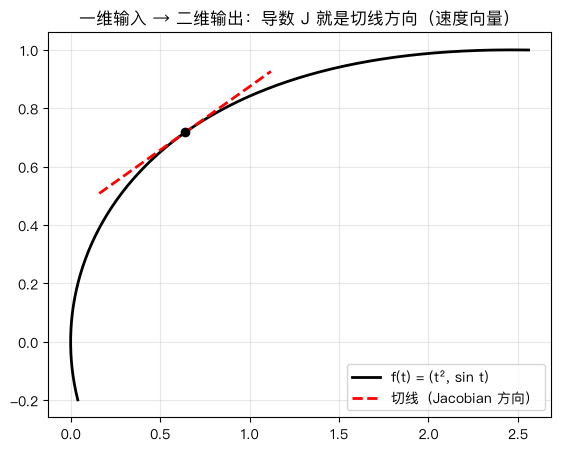

In [5]:
# 几何视角：参数曲线 f(t) = (t², sin t)，Jacobian J = f'(t) 就是切线方向
t0 = 0.8
ts = np.linspace(-0.2, 1.6, 200)
curve = np.array([ts**2, np.sin(ts)])
J = np.array([2*t0, np.cos(t0)])          # f'(t0)：1×1 的"Jacobian"

plt.figure(figsize=(6.5, 5))
plt.plot(curve[0], curve[1], 'k-', linewidth=2, label='f(t) = (t², sin t)')
t_span = np.linspace(-0.3, 0.3, 10)
tan = np.array([t0**2, np.sin(t0)])[:, None] + np.outer(J, t_span)
plt.plot(tan[0], tan[1], 'r--', linewidth=2, label='切线（Jacobian 方向）')
plt.scatter([t0**2], [np.sin(t0)], color='black', zorder=5)
plt.legend(); plt.grid(alpha=0.3)
plt.title('一维输入 → 二维输出：导数 J 就是切线方向（速度向量）')


## 4. 向量链式法则：Jacobian 相乘


### 4.1 公式

若 $z = g(y)$、$y = f(x)$，则复合映射 $z = g(f(x))$ 的 Jacobian：

$$J_z(x) = J_g(y)\cdot J_f(x)$$

**证明思路**：复合映射的局部线性化 = 两次线性化的复合，$g(f(x{+}\Delta x)) \approx g(f(x) + J_f\Delta x) \approx g(f(x)) + J_g J_f \Delta x$。这就是链式法则的矩阵形式：**导数矩阵相乘**。


In [6]:
# z = g(y), y = f(x)
f = lambda x: np.array([x[0]**2, x[0]*x[1]])
g = lambda y: np.array([y[0] + y[1], np.exp(y[0]*y[1])])
x0 = np.array([1.3, -0.6])

# 数值 J_z(x)
Jz_num = jacobian_numeric(lambda t: g(f(t)), x0)

# 解析 Jz = Jg·Jf
y0 = f(x0)
Jg = np.array([[1., 1.],
               [y0[1]*np.exp(y0[0]*y0[1]), y0[0]*np.exp(y0[0]*y0[1])]])
Jf = np.array([[2*x0[0], 0.],
               [x0[1], x0[0]]])
Jz_ana = Jg @ Jf

print("数值 J_z(x):\n", np.round(Jz_num, 6))
print("解析 Jg·Jf :\n", np.round(Jz_ana, 6))
print("最大误差:", np.abs(Jz_num - Jz_ana).max())


数值 J_z(x):
 [[ 2.        1.3     ]
 [-0.81409   0.587954]]
解析 Jg·Jf :
 [[ 2.        1.3     ]
 [-0.81409   0.587954]]
最大误差: 1.0902212466135097e-10


## 5. 反向传播 = 从后往前乘 Jacobian


### 5.1 两种相乘顺序

对 3 层复合 $L(x) = g(h(f(x)))$（标量损失 $L$）：

- **正向模式**：从左往右乘，$J_{g}\cdot J_{h}\cdot J_{f}$，每次乘都得到一个 $m\times n$ 矩阵
- **反向模式**：从右往左乘，先把最右的 $J_{f}$ 与"输出方向的向量"结合成向量-雅可比积（VJP），逐步往左

深度学习损失是**标量**（$m=1$），正向模式每一步都在算矩阵，反向模式每一步只算向量，成本差一个数量级。这也是"反向传播"这个名字的由来。

### 5.2 用 torch 验证多层网络梯度


In [7]:
torch.manual_seed(0)
n = 3
W1 = torch.randn(n, n, dtype=torch.float64, requires_grad=True)
W2 = torch.randn(n, n, dtype=torch.float64, requires_grad=True)
x0 = torch.randn(n, dtype=torch.float64)
target = torch.randn(n, dtype=torch.float64)

h1 = torch.tanh(W1 @ x0)
h2 = torch.tanh(W2 @ h1)
L = ((h2 - target) ** 2).sum()
L.backward()

# 用中心差分验证 ∂L/∂W1 的某一个元素
i, j = 0, 1
eps = 1e-6
W1p = W1.detach().clone(); W1p[i, j] += eps
W1m = W1.detach().clone(); W1m[i, j] -= eps
Lp = ((torch.tanh(W2 @ torch.tanh(W1p @ x0)) - target) ** 2).sum()
Lm = ((torch.tanh(W2 @ torch.tanh(W1m @ x0)) - target) ** 2).sum()
num = (Lp - Lm) / (2 * eps)

print(f"∂L/∂W1[{i},{j}] autograd = {W1.grad[i, j].item():.10f}")
print(f"∂L/∂W1[{i},{j}] 数值     = {num.item():.10f}")
print("一次 backward 得到全部", W1.grad.numel() + W2.grad.numel(), "个梯度")


∂L/∂W1[0,1] autograd = -0.1841757831
∂L/∂W1[0,1] 数值     = -0.1841757826
一次 backward 得到全部 18 个梯度


## 6. 向量-Jacobian 积（VJP）：深度学习真正用的东西


反向传播不存完整 Jacobian，只乘"上游梯度向量" $v$ 与 Jacobian 的积 $v^\mathsf{T} J$。对 $y = f(x)$（$n$ 输入、$m$ 输出），一个 $v$ 需要的乘法是 $O(mn)$，而完整 Jacobian 也是 $O(mn)$ 存储——但**用 VJP 逐层传播，每层只需一次矩阵-向量乘，总成本与参数个数线性**。代码验证：


In [8]:
x = torch.tensor([0.5, 1.2], dtype=torch.float64, requires_grad=True)
y = torch.stack([x[0]**2, x[0]*x[1], torch.sin(x[1])])   # R² → R³
v = torch.tensor([1.0, -2.0, 0.5], dtype=torch.float64)

# torch 的 VJP：grad_outputs 就是上游向量 v
vjp = torch.autograd.grad(y, x, grad_outputs=v)[0]

# 数值验证：vᵀJ
J = jacobian_numeric(lambda z: np.array([z[0]**2, z[0]*z[1], np.sin(z[1])]),
                     x.detach().numpy())
print("vᵀJ（torch）:", vjp.numpy())
print("vᵀJ（数值） :", v.numpy() @ J)
print("最大误差:", np.abs(vjp.numpy() - v.numpy() @ J).max())


vᵀJ（torch）: [-1.4        -0.81882112]
vᵀJ（数值） : [-1.4        -0.81882112]
最大误差: 7.827460901665972e-11


## 7. 与线性代数的呼应

- **Jacobian = 局部线性变换矩阵**：线性代数里的 $A$ 描述全局线性变换，Jacobian 描述"某点附近"的线性变换，两者都是矩阵、乘法法则一致
- **可逆 Jacobian 与隐函数定理**：若 $J$ 可逆（呼应线性代数中的可逆矩阵），则映射在局部是一对一的——这保证了很多理论分析成立
- 下一课把 Jacobian 再推一步：对梯度再求一次导，得到 **Hessian 矩阵**（多元二阶导）


## 课后练习


1. **手推 Jacobian**：$f(x,y) = (x^2 y,\, e^{xy},\, \ln(x{+}y))$，写出 $3\times 2$ Jacobian，用数值验证。
2. **逐元素函数**：证明 $f(x) = (\sin x_1, \dots, \sin x_n)$ 的 Jacobian 是对角阵，写出一般形式。
3. **复合**：$z = \sin(xy)$，$x = t^2$，$y = e^t$，用链式法则求 $dz/dt$ 在 $t=1$ 的值，并用数值差分验证。
4. **VJP**：对 $y = (x_1^2, x_1x_2, x_2^2)$，手算 $v^\mathsf{T}J$（$v=(1,2,3)$），与 `torch.autograd.grad` 对比。
5. **思考**：为什么标量损失下反向模式比正向模式划算？（提示：正向模式要存/乘 $m\times n$ 矩阵，反向模式只乘向量）
